In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.integrate import odeint

from rodeo.ibm import ibm_init
import ibm_nb
from rodeo.ode import *
from rodeo.fenrir import *
from rodeo.ode import _solve_filter
from double_filter import forward

from jax.config import config
config.update("jax_enable_x64", True)

def fitz(X_t, t, theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    V, R = X_t[:,0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                    [-1/c*(V - a + b*R)]])
def fitz_nb(X, t, theta):
    "FitzHugh-Nagumo ODE function for jax."
    a, b, c = theta
    p = len(X)//2
    V, R = X[0], X[p]
    return jnp.array([c*(V - V*V*V/3 + R),
                      -1/c*(V - a + b*R)])

def fitz2(X_t, t, theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    p = X_t.shape[1]//2
    V, R = X_t[0,[0, p]]
    return jnp.array([[c*(V - V*V*V/3 + R),
                       -1/c*(V - a + b*R)]])

In [2]:
# problem setup and intialization
n_deriv = 3  # Total state
n_var = 2  # Total measures
n_dim = 2

# it is assumed that the solution is sought on the interval [tmin, tmax].
n_res = 5
tmin = 0.
tmax = 20.
n_steps = int(n_res*tmax)
theta = np.array([0.2, 0.2, 3])
thetaj = jnp.array(theta)

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = .5
sigma = jnp.array([sigma]*n_var)

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)
W_block2 = np.zeros((1, n_var, n_var*n_deriv))
W_block2[0, 0, 1] = 1
W_block2[0, 1, 4] = 1
W_block2 = jnp.array(W_block2)

# Initial x0 for odeint
ode0 = np.array([-1., 1.])

# Initial x0 for jax block
# x0_block = jnp.array([[-1., 1., 1.], [1., 1/3, -0.3555555555555555]])
x0_block = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])
x0_block2 = jnp.array([[-1., 1., 0., 1., 1/3, 0.]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_steps
n_order = jnp.array([n_deriv]*n_var)
ode_init = ibm_init(dt, n_order, sigma)
ode_init2 = dict((k, jnp.expand_dims(jsp.linalg.block_diag(*v), 0)) for k, v in ode_init.items())
ode_init2['mean_state'] = ode_init2['mean_state'][:, 0, :]
tseq = jnp.linspace(tmin, tmax, n_steps+1)

# Jit solver
key = jax.random.PRNGKey(0)
sim_jit = jax.jit(solve_mv, static_argnums=(1, 7, 11))
sim, _ = sim_jit(key=key, fun=fitz,
        x0=x0_block, theta=thetaj,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init, interrogate=interrogate_tronarp)

sim2, _ = sim_jit(key=key, fun=fitz,
        x0=x0_block, theta=thetaj,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init, interrogate=interrogate_chkrebtii)
scan_out = forward

In [3]:
from probnum.diffeq import probsolve_ivp
import matplotlib.pyplot as plt
def fitz0(X_t, t, theta=theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])
def fitz1(t, X_t, theta=theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

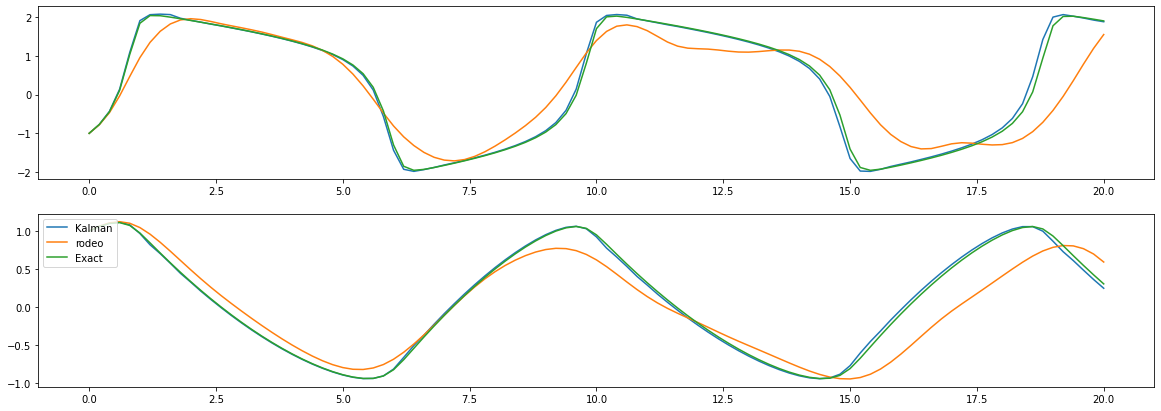

In [4]:

_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
for i in range(n_dim):
    axs[i].plot(tseq, sim[:,i, 0], label="Kalman")
    axs[i].plot(tseq, sim2[:,i, 0], label="rodeo")
    axs[i].plot(tseq, exact1[:, i], label='Exact')
axs[1].legend(loc='upper left')

In [6]:
key = jax.random.PRNGKey(0)
sim, _ = sim_jit(key=key, fun=fitz,
        x0=x0_block, theta=thetaj,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init, interrogate=interrogate_rodeo)

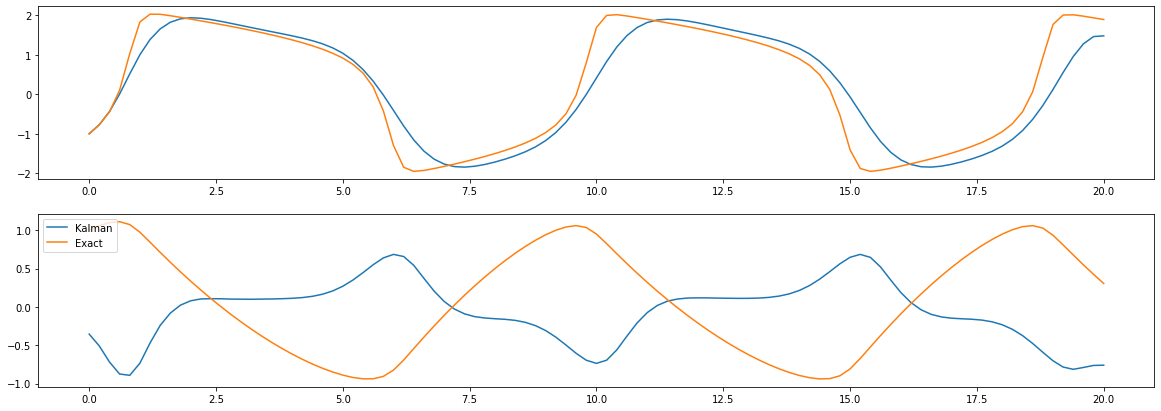

In [7]:

_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
for i in range(n_dim):
    axs[i].plot(tseq, sim[:,i, i*3], label="Kalman")
    axs[i].plot(tseq, exact1[:, i], label='Exact')
axs[1].legend(loc='upper left')

In [93]:
def fitz0(X_t, t, theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

n_obs = 40
tseq1 = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(fitz0, ode0, tseq1, args=(theta,))
#der = jnp.array([fitz0(exact[t],tseq[t],theta) for t in range(n_eval+1)])

gamma = .2
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

In [94]:

mean_obs = jnp.zeros((n_dim,))
trans_obs = np.zeros((n_var, n_deriv*n_var))
trans_obs[0, 0] = 1
trans_obs[1, 3] = 1
trans_obs = jnp.array(trans_obs)
var_obs = gamma**2*jnp.eye((n_dim))

In [95]:
x0_state = x0_block.flatten()

# Initial W for jax non block
W = np.zeros((n_var, n_var*n_deriv))
W[0, 1] = 1
W[1, 4] = 1
W = jnp.array(W)

ode_init = ibm_nb.ibm_init(dt, n_order, sigma)
kinit = ibm_nb.indep_init(ode_init, n_order)
ode_init = dict((k, jnp.array(v)) for k, v in kinit.items())
trans_state, mean_state, var_state = ode_init.values()

In [80]:
fenrir_jit = jax.jit(fenrir_filter, static_argnums=(0, 6))
m_smooth, v_smooth = fenrir_jit(fitz_nb, W, x0_state, theta, tmin, tmax, n_res,
                         trans_state, mean_state, var_state,
                         trans_obs, mean_obs, var_obs, obs)

In [32]:
filt_out, state_par, mean_smooth, var_smooth = rfenrir_filter(fitz_nb, W, x0_state, theta, tmin, tmax, n_res,
                         trans_state, mean_state, var_state,
                         trans_obs, mean_obs, var_obs, obs)

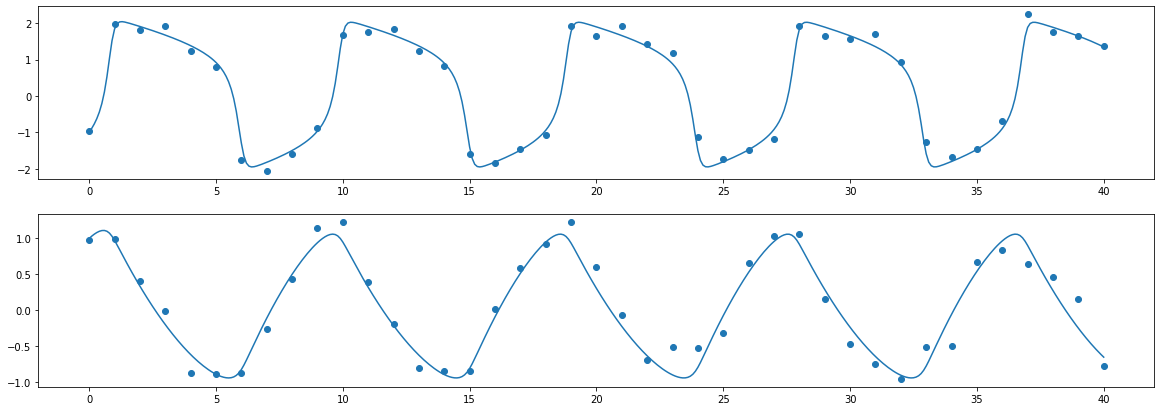

In [25]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
for i in range(n_dim):
    axs[i].plot(tseq, exact1[:, i], label='Exact')
    axs[i].plot(tseq, mean_smooth[:, i*3])
    axs[i].scatter(tseq1, obs[:, i], label='Obs')

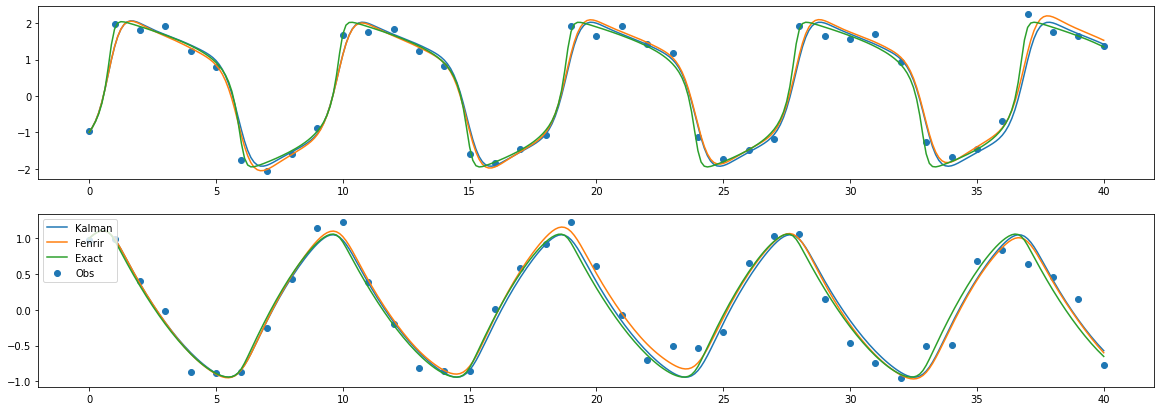

In [81]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
for i in range(n_dim):
    axs[i].plot(tseq, sim[:,i, 0], label="Kalman")
    axs[i].plot(tseq, m_smooth[:, i*3], label="Fenrir")
    #axs[i].plot(tseq, knum_sim[:, n_deriv_prior[0]*i], label="Kalman2")
    # axs[i].set_ylabel(ylabel[i])
    axs[i].plot(tseq, exact1[:, i], label='Exact')
    # axs[i].plot(tseq, filt_out['state_filt'][0][:, i*3])
    axs[i].scatter(tseq1, obs[:, i], label='Obs')
axs[1].legend(loc='upper left')

In [37]:
# ODE function
def ode_fun_jax(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t[:,0]
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([[dx], [dy], [dz]])

def lorenz_nb(X_t, t, theta):
    rho, sigma, beta = theta
    p = len(X_t) //3
    x, y, z = X_t[::p]
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([dx, dy, dz])

# problem setup and intialization
n_deriv = 3  # Total state; q
n_var = 3  # Total observations

# Time interval on which a solution is sought.
n_res = 1000
tmin = 0.
tmax = 20.
n_steps = int(n_res*tmax)
theta = jnp.array([28, 10, 8/3])

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = .5
sigma = jnp.array([sigma]*n_var)

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for jax block
x0_block = jnp.array([[-12., 70., 550.], [-5., 125, -1321.], [38., -124/3, -15658/9]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_steps  # step size
n_order = jnp.array([n_deriv]*n_var)
ode_init = ibm_init(dt, n_order, sigma)


In [38]:
def ode_fun(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return np.array([dx, dy, dz])

# Initial x0 for odeint
ode0 = np.array([-12, -5, 38])

# Get exact solutions for the Lorenz System
tseq = np.linspace(tmin, tmax, 201)
exact = odeint(ode_fun, ode0, tseq, args=(theta,), rtol=1e-20)
gamma = .2
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

In [39]:
n_dim = 3
mean_obs = jnp.zeros((n_dim,))
trans_obs = np.zeros((n_var, n_deriv*n_var))
trans_obs[0, 0] = 1
trans_obs[1, 3] = 1
trans_obs[2, 6] = 1
trans_obs = jnp.array(trans_obs)
var_obs = gamma**2*jnp.eye((n_dim))

In [40]:
x0_state = x0_block.flatten()
# Initial W for jax non block
W = np.zeros((n_var, n_var*n_deriv))
W[0, 1] = 1
W[1, 4] = 1
W[2, 7] = 1
W = jnp.array(W)

ode_init = ibm_nb.ibm_init(dt, n_order, sigma)
kinit = ibm_nb.indep_init(ode_init, n_order)
ode_init = dict((k, jnp.array(v)) for k, v in kinit.items())
trans_state, mean_state, var_state = ode_init.values()

In [41]:
fenrir_jit = jax.jit(fenrir_filter, static_argnums=(0, 6))
m_smooth, v_smooth = fenrir_jit(lorenz_nb, W, x0_state, theta, tmin, tmax, n_res//10,
                         trans_state, mean_state, var_state,
                         trans_obs, mean_obs, var_obs, obs)

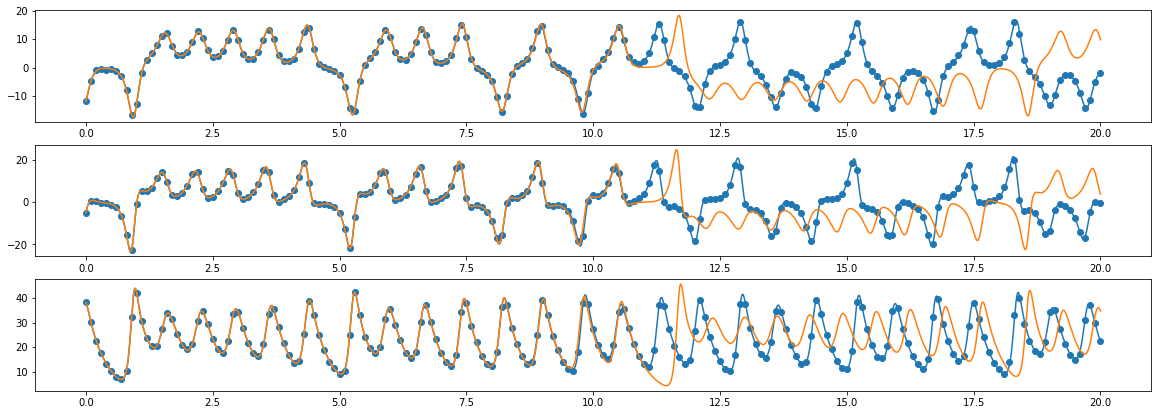

In [42]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['x', 'y', 'z']
tseq1 = np.linspace(tmin, tmax, n_steps+1)
exact1 = odeint(ode_fun, ode0, tseq1, args=(theta,), rtol=1e-20)
for i in range(n_dim):
    axs[i].plot(tseq1, exact1[:, i], label='Exact')
    axs[i].plot(tseq1, m_smooth[:, i*3])
    axs[i].scatter(tseq, obs[:, i], label='Obs')